In [178]:
import numpy as np
import matplotlib.pyplot as plt
import math
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import deepRD.tools.trajectoryTools as trajectoryTools
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

In [179]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [180]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(128,128)):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU(), nn.LayerNorm(h)]
            d = h
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def reparam(mu, logvar):
    eps = torch.randn_like(mu)
    return mu + eps * torch.exp(0.5 * logvar)

def softplus_floor(x, floor):
    # smooth lower bound: >= floor, with gradient
    return floor + F.softplus(x - floor)  # log(1 + exp(x - floor)) + floor

def sigmoid_box(x, lo, hi, temp=1.0):
    return lo + (hi - lo) * torch.sigmoid(temp * x)

class DiagGaussianHead(nn.Module):
    """Outputs (mu, log_sigma) for R^3."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.mlp = MLP(in_dim, out_dim, hidden=(128,128))
    def forward(self, x):
        out = self.mlp(x)
        mu, log_sig = out[..., :3], out[..., 3:]
        return mu, log_sig

# ---------- CVAE ----------
class CVAE(nn.Module):
    def __init__(self, idim=3, cdim=6, zdim=3, zdrop=0.15):
        super().__init__()
        self.cdim, self.zdim, self.zdrop = cdim, zdim, zdrop
        self.encoder = MLP(idim + cdim, out_dim=2*zdim, hidden=(128,128))
        self.prior   = MLP(cdim, out_dim=3*zdim, hidden=(160,160))
        self.decoder = DiagGaussianHead(zdim + cdim, 2*idim)
        
        self.z_prev = None
        self.df = nn.Parameter(torch.tensor(6.0))
        
    def attach_normalizers(self, scaler_v, scaler_r):
        """Attach normalization scalers for automatic preprocessing."""
        self.scaler_v = scaler_v
        self.scaler_r = scaler_r

    def encode(self, r_next, c):
        """ q(z|x,c) → μ_q, logσ²_q """
        q = self.encoder(torch.cat([r_next, c], dim=-1))
        q_mu, q_logv = q.split(self.zdim, dim=-1)
        return q_mu, q_logv

    def prior_params(self, c):
        """ p(z|c) → μ_p, logσ²_p, ρ (0<rho<1) """
        p = self.prior(c)
        p_mu, p_logv, raw_rho = p.split(self.zdim, dim=-1)
        
        p_logv = torch.clamp(p_logv, -1.8, 1.5)

        
        rho_min, rho_max, temp = 0.05, 0.9, 1.0
        rho = sigmoid_box(raw_rho, rho_min, rho_max, temp)  # (rho_min, rho_max)
        return p_mu, p_logv, rho

    def decode(self, z, c, p_cdrop=0.05):
        """ p(x|z,c) → μ_r, logσ²_r """
        
        if self.training and self.zdrop > 0:
            dropmask = (torch.rand_like(z) > self.zdrop).float()
            z = z * dropmask
        if self.training and p_cdrop>0:
            mask = (torch.rand_like(c) > p_cdrop).float()
            c = c * mask
            
        #mu, log_sig = self.decoder(torch.cat([z, c], dim=-1))
        #log_sig = torch.clamp(log_sig, min=-2.5, max=1.5)
        mu, raw_logsig = self.decoder(torch.cat([z, c], dim=-1))
        log_sig = softplus_floor(raw_logsig, floor=-1.2)  # try -1.5 first (σ_min ≈ 0.223)

        # homoscedastic noise so spikes can’t form
        #if not hasattr(self, "log_sigma_global"):
        #    self.log_sigma_global = nn.Parameter(torch.tensor(-2.0))   # σ0 ≈ 0.135
        #sigma_pred = torch.exp(log_sig)
        #sigma0     = torch.exp(self.log_sigma_global)
        #sigma_eff  = torch.sqrt(sigma_pred*sigma_pred + sigma0*sigma0)
        #log_sig    = torch.log(sigma_eff)

        return mu, log_sig, raw_logsig

    def forward(self, r_next, c, r_next_prev, c_prev, is_new_seq):
        
        """
        Forward pass of the conditional VAE with autoregressive prior.

        Args:
            r_next (Tensor): Target variable at the current step.
            c (Tensor): Conditioning variables (e.g., velocity, auxiliary state) at the current step.
            
            r_next_prev (Tensor): Target variable from the previous step (for teacher forcing).
            c_prev (Tensor): Conditioning variables from the previous step.
            
            is_new_seq (Tensor): Binary mask (0/1) indicating sequence boundaries 
                                 (1 for the start of a new sequence).

        Returns:
            dec_out (Tensor): Decoder output (reconstruction of r_next).
            (q_mu, q_logv) (Tuple[Tensor, Tensor]): Mean and log-variance of the posterior q(z|r_next, c).
            (ar_mu, p_logv) (Tuple[Tensor, Tensor]): Mean and log-variance of the autoregressive prior p(z_t|z_{t-1}, c).
            rho_eff (Tensor): Effective autoregressive coefficient
        """
        
        # current posterior
        q_mu, q_logv = self.encode(r_next, c)
        z_q = reparam(q_mu, q_logv)
        
        # prior (μ_p, σ_p, ρ) at current step
        p_mu, p_logv, rho = self.prior_params(c)
        
        # previous latent from previous step (teacher forcing)
        prev_q_mu, prev_q_logv = self.encode(r_next_prev, c_prev)
        z_prev = prev_q_mu.detach()
        
        #zero-out AR link at sequence starts
        if is_new_seq.dim() == 1:
            is_new_seq = is_new_seq.unsqueeze(-1)
        rho_eff = rho * (1.0 - is_new_seq)  # 0 at start; rho elsewhere
        
        # AR(1) prior mean
        ar_mu = rho_eff*z_prev + (1.0-rho_eff)*p_mu
        
        dec_out = self.decode(z_q, c)
        return dec_out, (q_mu, q_logv), (ar_mu, p_logv), rho_eff

    def reset_latent_state(self, batch_size=1):
        """Call at the start of a new simulation trajectory"""
        self.z_prev = torch.zeros(batch_size, self.zdim, device='cpu')

    @torch.no_grad()
    def sample_torch(self, c, Tz=1.0, Tr=1.0):
        """
        Sampling from torch tensor, no (de)normalisation.
        """
        if self.z_prev is None:
            self.reset_latent_state(batch_size=c.shape[0])
            
        p_mu, p_logv, rho = self.prior_params(c)
        #z = reparam(p_mu, p_logv)  # sample from p(z|c)
        z = rho * self.z_prev + (1 - rho) * p_mu + torch.exp(0.5 * p_logv) * torch.randn_like(p_mu) * Tz
        self.z_prev = z.detach()
        
        mu, log_sig, _ = self.decode(z, c)
        r = mu + torch.exp(log_sig) * torch.randn_like(mu) * Tr
        return r
    
    @torch.no_grad()
    def sample(self, c_n_np, Tr=1.0, Tz=1.0, device=None):
        """
        Sample r_{n+1} in physical units given c = [v_n, r_n] as NumPy array. 
        Built in normalisation of input and denormalisation of output.

        Args:
            c_n_np (np.ndarray): shape (..., 6)
            Tr (float): temperature scaling factor for stochasticity at output of decoder
            Tz (float): temperature scaling for latent space sample
            device (torch.device): GPU/CPU device to use (optional)

        Returns:
            np.ndarray: generated r_{n+1} in same physical scale as input
        """
        if device is None:
            device = next(self.parameters()).device
            
        if self.z_prev is None:
            self.reset_latent_state(batch_size=c_n_np.shape[0])

        # --- Normalize inputs ---
        v_n_np, r_n_np = c_n_np[...,:3], c_n_np[..., 3:]
        
        single_sample = False
        if r_n_np.ndim == 1:
            r_n_np = r_n_np.reshape(1, -1)
            v_n_np = v_n_np.reshape(1, -1)
            single_sample = True
        
        v_norm = self.scaler_v.transform(v_n_np)
        r_norm = self.scaler_r.transform(r_n_np)
        c = np.concatenate([v_norm, r_norm], axis=-1)

        # --- Convert to torch tensor ---
        c_t = torch.tensor(c, dtype=torch.float32, device=device)

        # --- Sample from conditional prior and decode ---
        r_next_norm_t = self.sample_torch(c_t, Tr=Tr, Tz=Tz)
        
        # --- De-normalize to physical scale ---
        r_next_np = r_next_norm_t.cpu().numpy()
        r_next_phys = self.scaler_r.inverse_transform(r_next_np)
        
        if single_sample:
            r_next_phys = r_next_phys.squeeze()  # (3,)

        return r_next_phys

In [181]:
def gaussian_nll_diag(x, mu, log_sig):
    # x, mu, log_sig: [..., 3]
    # Sum over dims; mean over batch
    return 0.5 * ((x - mu)**2 * torch.exp(-2*log_sig) + 2*log_sig + torch.log(torch.tensor(2*math.pi, device=x.device))).sum(-1).mean()

def student_t_nll(x, mu, log_s, df):
    # x, mu, log_s: [B,3]; df: scalar (>2)
    s2 = torch.exp(2*log_s)
    z  = (x - mu)**2 / s2
    d  = df
    # per-dim NLL, then sum over dims and mean over batch
    nll = 0.5*(torch.log(s2)) + 0.5*(d+1)*torch.log1p(z/d)
    # add constant term (ok to drop for training, include if you want exact NLL):
    # nll += 0.5*(torch.log(torch.tensor(math.pi*d))) + torch.lgamma((d+1)/2)-torch.lgamma(d/2)
    return nll.sum(-1).mean()


def kl_diag(q_mu, q_logv, p_mu, p_logv):
    # all [..., zdim]
    # KL(q||p) for diagonal Gaussians; mean over batch
    return 0.5 * (torch.exp(q_logv - p_logv) + (q_mu - p_mu)**2 * torch.exp(-p_logv) - 1 + p_logv - q_logv).sum(-1).mean()

def kl_free_bits(mu_q, logv_q, mu_p, logv_p, free_bits=0.5):
    kl_el = 0.5 * (
        torch.exp(logv_q - logv_p)
        + (mu_q - mu_p)**2 * torch.exp(-logv_p)
        - 1 + logv_p - logv_q
    )  # [B, zdim]
    kl_el = torch.clamp(kl_el, min=free_bits)
    return kl_el.sum(dim=-1).mean()

def free_bits_lambda(epoch, warm=30, decay_to=0.05, start=0.5, total=80):
    if epoch <= warm:
        return start - (start-0.2) * (epoch/warm)
    # decay further to decay_to
    t = min(1.0, (epoch - warm) / (total - warm))
    return 0.2 - (0.2 - decay_to) * t

def elbo_loss(r_next, dec_out, q, p, beta=1.0, full_cov=False):
    q_mu, q_logv = q
    p_mu, p_logv = p

    mu, log_sig = dec_out
    nll = gaussian_nll_diag(r_next, mu, log_sig)
    kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
    return nll + beta * kl, nll, kl

In [182]:
def train_cvae(model, train_loader, val_loader=None,
                epochs=50, lr=1e-3, beta_max=1.0, warmup_epochs=10, 
                grad_clip=1.0, save_path=None):

    # Loss history
    train_total, train_nll, train_kl = [], [], []
    val_total = []

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler()  # mixed precision
    
    for epoch in range(1, epochs+1):
        
        # ---- KL warm-up ----
        beta = beta_max * min(1.0, epoch/warmup_epochs)
            
        model.train()
        total_loss, total_nll, total_kl = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        for batch in loop:
            # Batch: (r_{n+1}, c, r_prev, c_prev, is_new)
            r_next, c, r_next_prev, c_prev, is_new = [x.to(device) for x in batch]
            #c = torch.cat([v_n, r_n], dim=-1)  # conditioning variable
            
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                dec_out, q, p, rho = model(r_next, c, r_next_prev, c_prev, is_new)
                q_mu, q_logv = q
                #p_mu, p_logv = p
                ar_mu, p_logv = p
                mu_r, log_sig_r, raw_logsig = dec_out

                nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
                #nll = student_t_nll(r_next, mu_r, log_sig_r, model.df)
                
                fb = free_bits_lambda(epoch, warm=30, decay_to=0.05, start=0.5, total=80)
                #kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
                kl  = kl_diag(q_mu, q_logv, ar_mu, p_logv)
                #kl = kl_free_bits(q_mu, q_logv, ar_mu, p_logv, free_bits=fb)

                #mean_match = 1e-4 * (q_mu.detach() - ar_mu).pow(2).mean()
                #var_reg    = 1e-4 * (p_logv**2).mean()
                dec_var_reg = 1e-4 * (log_sig_r**2).mean()
                
                loss = nll + beta*kl #+ mean_match + var_reg
                #loss = nll + beta * kl

            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            total_nll += nll.item()
            total_kl += kl.item()

            loop.set_postfix(loss=loss.item(), NLL=nll.item(), KL=kl.item())

        scheduler.step()
        print(f"Epoch {epoch}: loss={total_loss/len(train_loader):.4f}, "
              f"NLL={total_nll/len(train_loader):.4f}, KL={total_kl/len(train_loader):.4f}")
        
        train_total.append(total_loss/len(train_loader))
        train_nll.append(total_nll/len(train_loader))
        train_kl.append(total_kl/len(train_loader))
        
        # ---- optional validation ----
        if val_loader is not None and epoch % 5 == 0:
            val_loss = evaluate_cvae(model, val_loader, beta)
            print(f"Validation loss: {val_loss:.4f}")
            val_total.append(val_loss)
            
        with torch.no_grad():
            # per-dim KL
            kl_el = 0.5*(torch.exp(q_logv-p_logv) + (q_mu-ar_mu)**2*torch.exp(-p_logv) -1 + p_logv - q_logv)
            print("KL per-dim:", kl_el.mean(0).cpu().numpy(), 'FB per-dim:', fb)
            print("rho mean/max:", rho.mean().item(), rho.max().item())
            # clamp hit rates
            print("prior σ floor hits:", (p_logv <= -1.5+1e-6).float().mean().item())
            print("dec σ floor hits:", (raw_logsig <= -1.5+1e-6).float().mean().item())
            
            # Convert log-variances to standard deviations
            dec_sigma = torch.exp(log_sig_r)            # [batch, 3]
            prior_sigma = torch.exp(0.5 * p_logv)       # [batch, zdim]

            # Batch means (averaged over both batch and dimensions)
            dec_sigma_mean = dec_sigma.mean().item()
            prior_sigma_mean = prior_sigma.mean().item()

            print(f"decoder_sigma_mean={dec_sigma_mean:.3f}, prior_sigma_mean={prior_sigma_mean:.3f}")


        if save_path:
            torch.save({'model_state': model.state_dict()}, save_path)
            
    return {
        "train_total": train_total,
        "train_nll": train_nll,
        "train_kl": train_kl,
        "val_total": val_total,
    }

In [183]:
@torch.no_grad()
def evaluate_cvae(model, loader, beta=1.0):
    model.eval()
    total = 0
    for batch in loader:
        r_next, c, r_next_prev, c_prev, is_new = [x.to(device) for x in batch]

        dec_out, q, p, _ = model(r_next, c, r_next_prev, c_prev, is_new)
        q_mu, q_logv = q
        ar_mu, p_logv = p
        mu_r, log_sig_r, _ = dec_out
        
        nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
        kl  = kl_diag(q_mu, q_logv, ar_mu, p_logv)
        total += (nll + beta*kl).item()
    return total / len(loader)

In [184]:
class RVDatasetAR1(Dataset):
    """
    Build (t-1, t) pairs per trajectory for AR(1) teacher forcing.
    v_trajs, r_trajs: lists of arrays with shape [T, 3] each.
    """
    def __init__(self, v_trajs, r_trajs, show_progress=True):
        assert len(v_trajs) == len(r_trajs)
        self.samples = []  # list of dicts for flexibility

        iterator = tqdm(range(len(v_trajs)), desc="Building RVDatasetAR1") if show_progress else range(len(v_trajs))
        for i in iterator:
            v = v_trajs[i]
            r = r_trajs[i]
            T = len(v)
            # we need t>=1 so that c_{t-1} exists; target is r_{t+1} so t<=T-2
            for t in range(1, T-1):
                #c_t = np.concatenate([v[t],   r[t]],   axis=-1)
                c_t = torch.cat([v[t], r[t]], dim=-1) # [6]
                c_p = torch.cat([v[t-1], r[t-1]], dim=-1) # [6]
                self.samples.append({
                    "r_next": r[t+1],  # [3]
                    "c":      c_t,      # [6]
                    "r_next_prev": r[t],     # [3]
                    "c_prev": c_p,      # [6]
                    "is_new": torch.tensor(1.0 if t == 1 else 0.0),
                })

        if show_progress:
            print(f"✔ Finished building dataset. Total samples: {len(self.samples)}")
            
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return (
            s["r_next"],
            s["c"],
            s["r_next_prev"],
            s["c_prev"],
            s["is_new"]
        )

In [185]:
# System type: 'bistable', 'dimer'
systemType = 'bistable'

# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi
conditionedOn = 'piri'

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim
# for dimer, alternating between particle 1 and particle 2.

# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 200
train_split = 0.8

# Sample simulation files randomly
fnums = np.random.choice(2500, n_datasets, replace=False)
print(np.sort(fnums))
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)
        
n_timesteps = dataset.shape[1]

# Dataset - training data
dataset.shape, dataset.flatten(end_dim=1).shape, n_timesteps, dataset.dtype

[   8   19   48   52   54   55   74   85   93  122  129  154  156  174
  193  197  200  201  202  273  279  285  286  294  302  319  325  358
  413  420  440  443  490  503  507  514  524  560  574  577  584  592
  593  606  635  636  663  670  673  682  704  710  729  743  754  792
  809  855  857  877  885  889  904  936  938  949  952  972  985  989
  994 1013 1016 1026 1028 1051 1062 1095 1119 1123 1127 1134 1137 1150
 1155 1163 1164 1177 1198 1201 1205 1233 1258 1262 1275 1286 1294 1295
 1302 1306 1320 1321 1329 1333 1334 1335 1351 1358 1362 1386 1391 1402
 1418 1422 1433 1441 1481 1494 1534 1553 1555 1564 1574 1581 1588 1592
 1628 1653 1664 1681 1685 1694 1699 1702 1707 1714 1721 1722 1730 1764
 1804 1837 1844 1877 1883 1904 1912 1927 1935 1944 1950 1973 1985 2010
 2012 2015 2020 2031 2054 2058 2067 2069 2070 2077 2107 2114 2115 2118
 2119 2123 2141 2163 2174 2180 2191 2225 2227 2240 2251 2277 2278 2281
 2288 2300 2316 2341 2346 2360 2389 2390 2404 2412 2429 2439 2448 2459
 2463 

(torch.Size([200, 10000, 11]), torch.Size([2000000, 11]), 10000, torch.float32)

In [186]:
q = dataset[..., 1:4]   # position (not used now, but may be later)
v = dataset[..., 4:7]   # velocity
r = dataset[..., 8:11]  # auxiliary var

In [187]:
v_n = v.reshape(-1, 3)
r_n = r.reshape(-1, 3)
r_next = r[:, 1:-1, :].reshape(-1, 3)

r_next_val = r_next[int(0.8*len(r_next)):]

In [188]:
## Normalization

scaler_v = StandardScaler().fit(v_n)
scaler_r = StandardScaler().fit(r_n)

v_norm = torch.tensor(scaler_v.transform(v_n), dtype=torch.float32).reshape(n_datasets, n_timesteps, 3)
r_norm = torch.tensor(scaler_r.transform(r_n), dtype=torch.float32).reshape(n_datasets, n_timesteps, 3)

In [189]:
r_n.mean(), r_n.std(), v_n.mean(), v_n.std(), v_norm.mean(), v_norm.std(), r_norm.mean(), r_norm.std()

(tensor(-3.0810e-08),
 tensor(0.0162),
 tensor(-0.0003),
 tensor(0.1426),
 tensor(0.),
 tensor(1.0000),
 tensor(1.5259e-11),
 tensor(1.0000))

In [98]:
## Saving Scaler Params

joblib.dump(
    {
        "scaler_v": scaler_v,
        "scaler_r": scaler_r
    },
    "normalizers_ar.pkl"
)

['normalizers_ar.pkl']

In [99]:
N = len(r_norm)
split = int(0.8*N)

In [100]:
#train_ds = RVDataset(r_next_norm[:split], v_n_norm[:split], r_n_norm[:split])
#val_ds   = RVDataset(r_next_norm[split:], v_n_norm[split:], r_n_norm[split:])

train_ds = RVDatasetAR1(v_norm[:split], r_norm[:split])
val_ds = RVDatasetAR1(v_norm[split:], r_norm[split:])

Building RVDatasetAR1: 100%|█████████████████████████████████████████| 160/160 [00:38<00:00,  4.18it/s]


✔ Finished building dataset. Total samples: 1599680


Building RVDatasetAR1: 100%|███████████████████████████████████████████| 40/40 [00:07<00:00,  5.44it/s]


✔ Finished building dataset. Total samples: 399920


In [101]:
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=4096, shuffle=False, num_workers=4)

model = CVAE()

In [102]:
losses = train_cvae(model,
                    train_loader,
                    val_loader=val_loader,
                    epochs=50,
                    lr=1e-3,
                    beta_max=1.5,
                    warmup_epochs=20,
                    grad_clip=1.0,
                    save_path="cvae_ar_checkpoint.pt")

/srv/data/jakut77/miniconda3/envs/pyta/lib/python3.12/site-packages/torch/amp/grad_scaler.py:131: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
Epoch 1/50:   0%|                                                              | 0/391 [00:00<?, ?it/s]/srv/data/jakut77/miniconda3/envs/pyta/lib/python3.12/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch 1/50: 100%|███████████████████| 391/391 [00:13<00:00, 28.77it/s, KL=5.76, NLL=-0.408, loss=-0.12]


Epoch 1: loss=0.2135, NLL=-0.0295, KL=4.8602
KL per-dim: [1.9741048 1.8737974 1.910522 ] FB per-dim: 0.49
rho mean/max: 0.2702966630458832 0.8752802014350891
prior σ floor hits: 0.3166666626930237
dec σ floor hits: 0.9311012029647827
decoder_sigma_mean=0.285, prior_sigma_mean=0.679


Epoch 2/50: 100%|█████████████████| 391/391 [00:13<00:00, 29.14it/s, KL=4.55, NLL=-0.46, loss=-0.00446]


Epoch 2: loss=-0.0040, NLL=-0.4621, KL=4.5817
KL per-dim: [1.534409  1.4696424 1.5466404] FB per-dim: 0.48
rho mean/max: 0.25492042303085327 0.8854469656944275
prior σ floor hits: 0.22827380895614624
dec σ floor hits: 0.933779776096344
decoder_sigma_mean=0.282, prior_sigma_mean=0.715


Epoch 3/50: 100%|███████████████████| 391/391 [00:13<00:00, 28.80it/s, KL=3.96, NLL=-0.332, loss=0.263]


...

Epoch 49/50: 100%|████████████████████| 391/391 [00:13<00:00, 28.19it/s, KL=0.598, NLL=0.79, loss=1.69]


Epoch 49: loss=1.6939, NLL=0.7747, KL=0.6128
KL per-dim: [0.01218614 0.30124506 0.28412074] FB per-dim: 0.14300000000000002
rho mean/max: 0.20231899619102478 0.8905914425849915
prior σ floor hits: 0.2555059492588043
dec σ floor hits: 0.8626487851142883
decoder_sigma_mean=0.308, prior_sigma_mean=0.545


Epoch 50/50: 100%|███████████████████| 391/391 [00:13<00:00, 28.49it/s, KL=0.574, NLL=0.688, loss=1.55]

Epoch 50: loss=1.6930, NLL=0.7740, KL=0.6127


Validation loss: 1.5601
KL per-dim: [0.00981059 0.2915931  0.27223805] FB per-dim: 0.14
rho mean/max: 0.21550023555755615 0.8900003433227539
prior σ floor hits: 0.23377975821495056
dec σ floor hits: 0.8590773940086365
decoder_sigma_mean=0.309, prior_sigma_mean=0.548


In [103]:
train_total_losses, train_nll_losses, train_kl_losses, val_total_losses = losses.values()

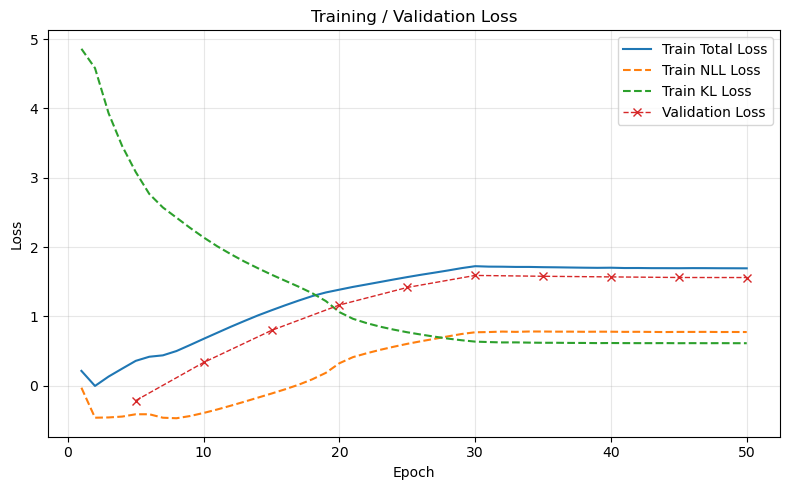

In [104]:
epochs_range = range(1, len(train_total_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_total_losses, label='Train Total Loss')
plt.plot(epochs_range, train_nll_losses, label='Train NLL Loss', linestyle='--')
plt.plot(epochs_range, train_kl_losses, label='Train KL Loss', linestyle='--')

if len(val_total_losses) > 0:
    plt.plot(epochs_range[4::5], val_total_losses, 'x--', label='Validation Loss', linewidth=1)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [105]:
valModel = CVAE()

scalers = joblib.load("normalizers_ar.pkl")
valModel.attach_normalizers(**scalers)
ckpt = torch.load("cvae_ar_checkpoint.pt", map_location="cpu")
valModel.load_state_dict(ckpt['model_state'])

<All keys matched successfully>

In [108]:
def dataset_to_arrays(dataset):
    r_next_list, c_list, r_next_prev_list, c_prev_list = [], [], [], []
    for i in range(len(dataset)):
        r_next, c, r_prev, c_prev, _ = dataset[i]
        r_next_list.append(r_next.numpy())
        c_list.append(c.numpy())
        r_next_prev_list.append(r_prev.numpy())
        c_prev_list.append(c_prev.numpy())
    return (
        np.stack(r_next_list),
        np.stack(c_list),
        np.stack(r_next_prev_list),
        np.stack(c_prev_list),
    )

def dataset_to_tensors(dataset, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    r_next_list, c_list, r_next_prev_list, c_prev_list = [], [], [], []
    for i in range(len(dataset)):
        r_next, c, r_next_prev, c_prev, _ = dataset[i]
        r_next_list.append(r_next)
        c_list.append(c)
        r_next_prev_list.append(r_next_prev)
        c_prev_list.append(c_prev)

    return (
        torch.stack(r_next_list).to(device),
        torch.stack(c_list).to(device),
        torch.stack(r_next_prev_list).to(device),
        torch.stack(c_prev_list).to(device),
    )

In [165]:
def plot_r_distributions(model, r_next, c_n, r_next_prev=None, c_prev=None,
                         n_samples=50000, device="cpu", Tr=1.0, Tz=1.0):
    """
    Compare benchmark, reconstructed, and generated distributions of r_{n+1}.

    Args:
        model: trained CVAE model with attached scalers (scaler_v, scaler_r)
        c_n (np.ndarray): conditioning vectors [v_n, r_n], shape [N, 6]
        r_next (np.ndarray): true target auxiliary variable, shape [N, 3]
        r_prev (np.ndarray, optional): r_{n}, shape [N, 3]; required for reconstruction
        c_prev (np.ndarray, optional): [v_{n-1}, r_{n-1}], shape [N, 6]; required for reconstruction
        n_samples: number of samples to draw for visualization
        device: torch device
        Tr, Tz: sampling temperatures for decoder and latent
    """
    model.eval()

    # --- Subsample for efficiency ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]

    if r_next_prev is not None:
        r_next_prev_s = r_next_prev[idx]
    if c_prev is not None:
        c_prev_s = c_prev[idx]

    # INPUT DATA IS ALREADY NORMALISED
        
    # --- Normalize using model scalers ---
    #v_norm = model.scaler_v.transform(c_s[:, :3])
    #r_norm = model.scaler_r.transform(c_s[:, 3:])
    #c_norm = np.concatenate([v_norm, r_norm], axis=-1)
    

    #if r_prev is not None:
    #    r_prev_norm = model.scaler_r.transform(r_prev_s)
    #if c_prev is not None:
    #    v_prev_norm = model.scaler_v.transform(c_prev_s[:, :3])
    #    r_prev_prev_norm = model.scaler_r.transform(c_prev_s[:, 3:])
    #    c_prev_norm = np.concatenate([v_prev_norm, r_prev_prev_norm], axis=-1)

    # --- Convert to torch tensors ---
    #c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
    #r_next_t = torch.tensor(model.scaler_r.transform(r_next_s), dtype=torch.float32, device=device)

    # --- Reconstruction (using true previous step) ---
    if r_prev is not None and c_prev is not None:
        #r_prev_t = torch.tensor(r_prev_norm, dtype=torch.float32, device=device)
        #c_prev_t = torch.tensor(c_prev_norm, dtype=torch.float32, device=device)
        is_new_seq = torch.zeros(len(c_s), 1, device=device)

        with torch.no_grad():
            (mu_r, log_sig_r, _), _, _, _ = model(
                r_next_s, c_s, r_next_prev_s, c_prev_s, is_new_seq
            )
            # stochastic reparam
            r_rec_norm = mu_r + torch.exp(log_sig_r) * torch.randn_like(mu_r) * Tr
            r_rec = model.scaler_r.inverse_transform(r_rec_norm.cpu().numpy())
    else:
        r_rec = None

    # --- Generated samples (purely from prior) ---
    with torch.no_grad():
        r_gen_norm = model.sample_torch(c_s, Tr=Tr, Tz=Tz)
        r_gen = model.scaler_r.inverse_transform(r_gen_norm.numpy())

    # --- Benchmark data (already physical scale) ---
    r_bench = model.scaler_r.inverse_transform(r_next_s.cpu().numpy())

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = ["r_x", "r_y", "r_z"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for i, ax in enumerate(axes):
        kde_bench = gaussian_kde(r_bench[:, i])
        xs = np.linspace(
            min(r_bench[:, i].min(),
                r_gen[:, i].min() if r_gen is not None else r_bench[:, i].min()),
            max(r_bench[:, i].max(),
                r_gen[:, i].max() if r_gen is not None else r_bench[:, i].max()),
            300,
        )
        ax.plot(xs, kde_bench(xs), label="Benchmark", color=colors[i], lw=2)

        if r_rec is not None:
            kde_rec = gaussian_kde(r_rec[:, i])
            ax.plot(xs, kde_rec(xs), "--", color="black", lw=1.5, label="Reconstructed")

        kde_gen = gaussian_kde(r_gen[:, i].flatten())
        ax.plot(xs, kde_gen(xs), ":", color="red", lw=1.5, label="Generated")

        ax.set_title(f"Distribution of {labels[i]}")
        ax.set_xlabel(labels[i])
        ax.set_ylabel("Density")
        ax.set_xlim(-0.05, 0.05)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [166]:
# Assume you have:
# r_n, v_n, r_next = benchmark arrays (each [N,3])
# model = trained CVAE with attached scalers
#r_next, c, r_prev, c_prev = dataset_to_arrays(val_ds)
val_ts = dataset_to_tensors(val_ds)

In [167]:
val_ts[0].mean(), val_ts[1].mean(), val_ts[2].mean(), val_ts[3].mean(),val_ts[0].std(), val_ts[1].std(), val_ts[2].std(), val_ts[3].std()

(tensor(-0.0018),
 tensor(-0.0017),
 tensor(-0.0018),
 tensor(-0.0017),
 tensor(1.0019),
 tensor(1.0047),
 tensor(1.0019),
 tensor(1.0047))

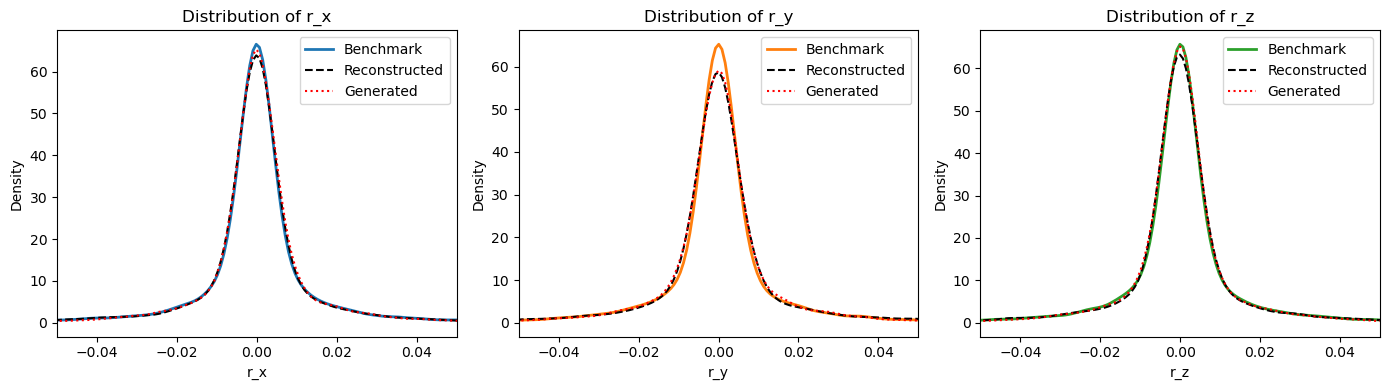

In [168]:
plot_r_distributions(valModel, *val_ts, n_samples=20000, device=device, Tr=1, Tz=1)

In [169]:
def visualize_latent_distributions(model, r_next, c_n, r_next_prev=None, c_prev=None,
                                   n_samples=50000, device="cpu"):
    """
    Visualize latent space distributions for encoder vs conditional AR(1) prior.

    Args:
        model: trained CVAE with attached scalers (scaler_v, scaler_r)
        r_next (np.ndarray): true target r_{n+1}
        c_n (np.ndarray): conditioning variables [v_n, r_n]
        r_next_prev (np.ndarray, optional): previous r_n
        c_prev (np.ndarray, optional): previous conditioning [v_{n-1}, r_{n-1}]
        n_samples: number of samples to analyze
        device: torch device
    """
    model.eval()

    # --- Subsample ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]
    if r_next_prev is not None:
        r_next_prev_s = r_prev[idx]
    if c_prev is not None:
        c_prev_s = c_prev[idx]

    # --- Normalize conditioning and targets ---
    #v_norm = model.scaler_v.transform(c_s[:, :3])
    #r_norm = model.scaler_r.transform(c_s[:, 3:])
    #c_norm = np.concatenate([v_norm, r_norm], axis=-1)

    #r_next_norm = model.scaler_r.transform(r_next_s)

    #if r_prev is not None:
    #    r_prev_norm = model.scaler_r.transform(r_prev_s)
    #if c_prev is not None:
    #    v_prev_norm = model.scaler_v.transform(c_prev_s[:, :3])
    #    r_prev_prev_norm = model.scaler_r.transform(c_prev_s[:, 3:])
    #    c_prev_norm = np.concatenate([v_prev_norm, r_prev_prev_norm], axis=-1)

    # --- Convert to torch tensors ---
    #c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
    #r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)

    # --- Forward pass to get latent distributions ---
    with torch.no_grad():
        if r_next_prev is not None and c_prev is not None:
            is_new_seq = torch.zeros(len(c_s), 1, device=device)
            _, (q_mu, q_logv), _, _ = model(r_next_s, c_s, r_next_prev_s, c_prev_s, is_new_seq)
        else:
            # Simpler (non-AR) pass if prev data not given
            q_mu, q_logv = model.encode(r_next_s, c_s)

        # Always compute prior for comparison
        p_mu, p_logv, rho = model.prior_params(c_s)

    # --- Move to numpy ---
    q_mu, q_logv = q_mu.cpu().numpy(), q_logv.cpu().numpy()
    p_mu, p_logv = p_mu.cpu().numpy(), p_logv.cpu().numpy()

    q_std = np.exp(0.5 * q_logv)
    p_std = np.exp(0.5 * p_logv)
    zdim = q_mu.shape[1]

    # --- Plot histograms ---
    fig, axes = plt.subplots(2, zdim, figsize=(4*zdim, 6))
    for i in range(zdim):
        # Means
        ax = axes[0, i]
        ax.hist(q_mu[:, i], bins=50, alpha=0.6, label="Encoder μ_q", color="tab:blue")
        ax.hist(p_mu[:, i], bins=50, alpha=0.6, label="Prior μ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: means")
        ax.legend()

        # Standard deviations
        ax = axes[1, i]
        ax.hist(q_std[:, i], bins=50, alpha=0.6, label="Encoder σ_q", color="tab:blue")
        ax.hist(p_std[:, i], bins=50, alpha=0.6, label="Prior σ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: stds")
        ax.legend()

    plt.tight_layout()
    plt.show()

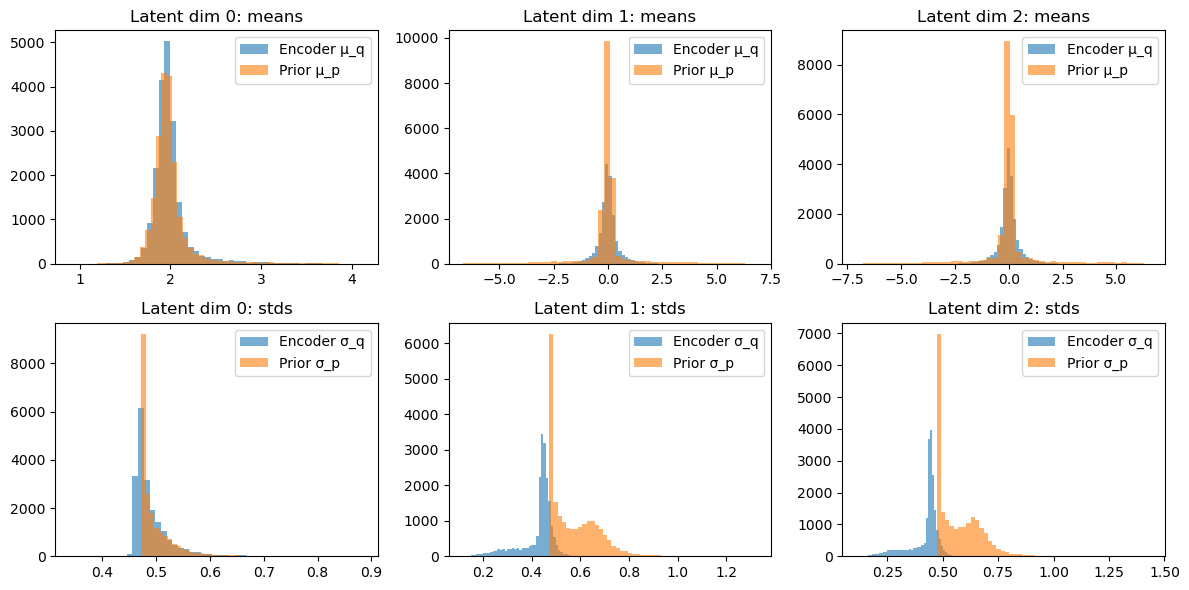

In [170]:
# Assuming you have arrays from benchmark data
# r_n, v_n, r_next -> each [N, 3]
visualize_latent_distributions(valModel, *val_ts, n_samples=20000)

In [171]:
batch = next(iter(val_loader))
r_nxt_b, c_t, r_prev_b, c_prev_b, is_new_seq_b = batch

with torch.no_grad():
    dec_out, (q_mu,q_logv), (p_mu,p_logv), _ = valModel(r_nxt_b, c_t, r_prev_b, c_prev_b, is_new_seq_b)
    q_std = torch.exp(0.5*q_logv).mean().item()
    p_std = torch.exp(0.5*p_logv).mean().item()
    mu_r, log_sig_r, _ = dec_out
    r_std = torch.exp(log_sig_r).mean().item()
print(f"mean q_std={q_std:.3f}  p_std={p_std:.3f}  decoder_sigma={r_std:.3f}")

mean q_std=0.446  p_std=0.546  decoder_sigma=0.294


In [172]:
def stats(x): 
    x = x.detach().cpu().numpy().reshape(-1)
    qs = np.quantile(x, [0.1,0.5,0.9])
    return f"mean={x.mean():.3f} q10={qs[0]:.3f} q50={qs[1]:.3f} q90={qs[2]:.3f}"
print("p_std:", stats(torch.exp(0.5*p_logv)))
print("q_std:", stats(torch.exp(0.5*q_logv)))
print("dec σ:", stats(torch.exp(log_sig_r)))

p_std: mean=0.546 q10=0.472 q50=0.502 q90=0.682
q_std: mean=0.446 q10=0.356 q50=0.458 q90=0.504
dec σ: mean=0.294 q10=0.223 q50=0.223 q90=0.474
